# 3. Cross-asset relative value (Hypothesis 2)

**Question.** Do economically linked pairs produce residuals that mean-revert, and is the mean reversion tradable?

> **Data provenance.** This notebook runs on whichever source the pipeline was given. When the
> source is `SYNTHETIC`, every number below is a property of the simulator in `src/synthetic.py`
> and **not** market history. The only observed market values in the project are the three
> anchors in `config.ANCHORS`. Run `python run_pipeline.py --source fred` on a machine with
> network access to reproduce the identical analysis from live data.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import backtest, config, features, pipeline, regressions, relative_value, signals

# src.charts selects the Agg backend so the pipeline runs headless; switch back to the
# inline backend afterwards so figures render in the notebook.
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

results = pipeline.run(write_outputs=False)
provenance = results["dataset"].provenance()
print(f"source        {provenance['source']}")
print(f"window        {provenance['start_date']} to {provenance['end_date']}")
print(f"observations  {provenance['daily_observations']:,} trading days")
print(f"validation    {results['validation_log'].summary()}")


source        SYNTHETIC
window        2016-08-15 to 2026-08-13
observations  2,512 trading days
validation    PASS=54


## Pairs were chosen from economics, not from Sharpe ratios

Each pair carries the prior that motivated it. The primary pair is the one with the cleanest theoretical link, fixed before any backtest was run.

In [2]:
for pair in relative_value.PAIRS:
    marker = " (PRIMARY)" if pair.name == relative_value.PRIMARY_PAIR else ""
    print(f"{pair.name}{marker}\n  {pair.y} ~ {pair.x}\n  {pair.rationale}\n")

gold_real10 (PRIMARY)
  gold ~ real10
  Gold is a zero-coupon real asset with no cash flows, so its price should fall as the real risk-free rate rises and the opportunity cost of holding it increases. This is the cleanest theoretical link in the universe and is the pre-specified primary pair.

wti_usd
  wti ~ usd
  Crude is invoiced in dollars, so a stronger dollar mechanically raises the local-currency cost for non-US buyers and weighs on the dollar price.

breakeven_wti
  breakeven10 ~ wti
  Energy passes into headline inflation, and 10y breakevens historically track the oil complex even though the pass-through to a decade of inflation should be small. Extremes in the residual are candidate over-reactions.

spx_vix
  spx ~ vix
  Implied volatility is a price of insurance on the index, so the two are mechanically linked. The residual measures whether volatility is high or low relative to where the index is trading.

curve_hyoas
  curve_2s10s ~ hy_oas
  The curve and credit spreads bot

## The spurious regression

Two trending near-unit-root series can produce a large, significant, and economically wrong beta in levels. Comparing the levels and differenced estimates makes it visible instead of leaving it buried.

In [3]:
rv = results["rv_relationships"]
rv[["pair", "beta", "beta_t", "r_squared", "beta_changes", "beta_changes_t",
    "r_squared_changes", "corr_changes", "sign_agrees_with_changes"]]

,pair,beta,beta_t,r_squared,beta_changes,beta_changes_t,r_squared_changes,corr_changes,sign_agrees_with_changes
0,gold_real10,0.0462,7.6105,0.0226,-0.0845,-22.5327,0.2392,-0.4891,False
1,wti_usd,0.3457,2.7462,0.0030,-1.8058,-10.1331,0.0622,-0.2494,False
2,breakeven_wti,0.7682,27.2814,0.2287,0.7324,20.0738,0.2352,0.4849,True
3,spx_vix,-0.4475,-30.8296,0.2747,-0.0813,-15.9266,0.3504,-0.5920,True
4,curve_hyoas,-1.5390,-2.4426,0.0024,-5.7139,-4.3452,0.0139,-0.1177,True


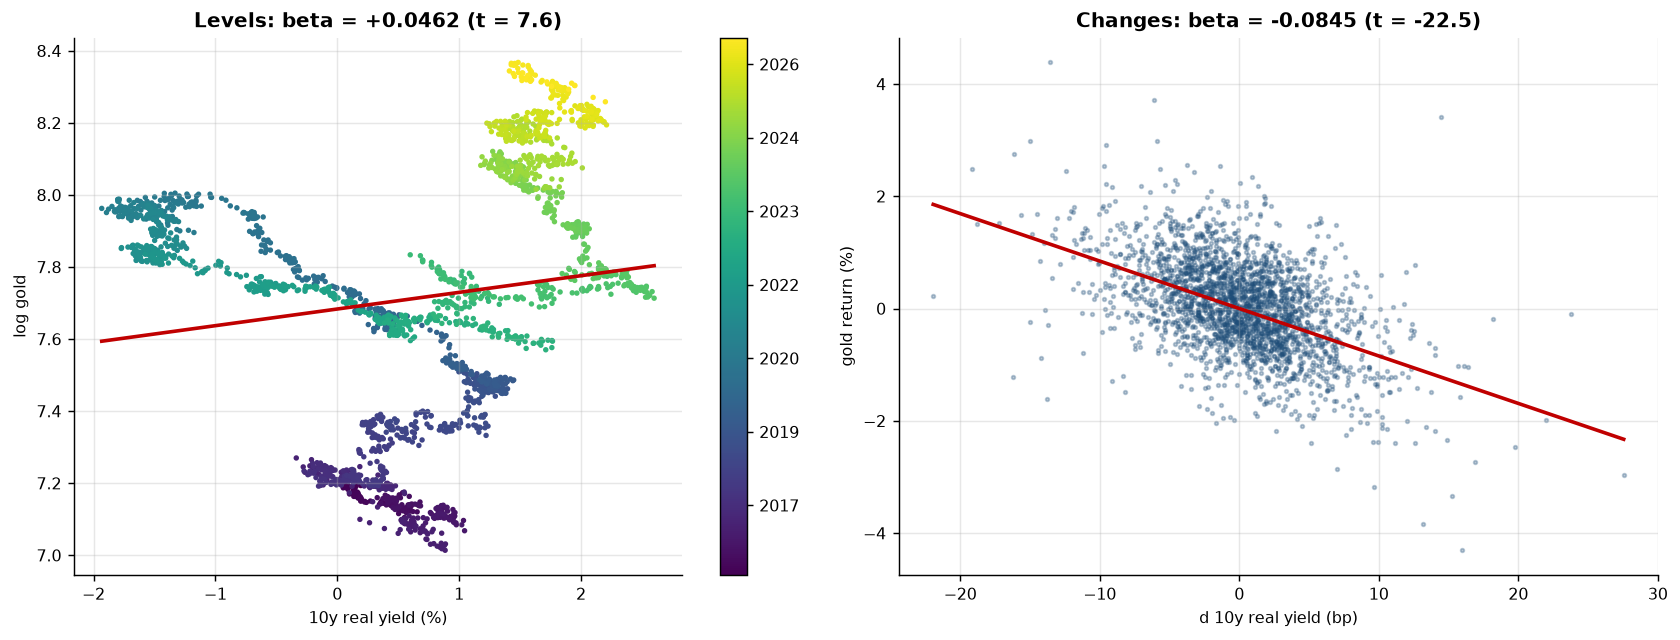

In [4]:
import matplotlib.dates as mdates

panel = results["panel"]
row = rv.set_index("pair").loc[relative_value.PRIMARY_PAIR]
log_gold, real = np.log(panel["gold"]), panel["real10"]
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5))
sc = left.scatter(real, log_gold, c=mdates.date2num(panel.index), cmap="viridis", s=4)
grid = np.linspace(real.min(), real.max(), 50)
left.plot(grid, row["alpha"] + row["beta"] * grid, color="#c00000", linewidth=2)
left.set_xlabel("10y real yield (%)"); left.set_ylabel("log gold"); left.grid(alpha=0.3)
left.set_title(f"Levels: beta = {row['beta']:+.4f} (t = {row['beta_t']:.1f})")
bar = fig.colorbar(sc, ax=left); bar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ch = pd.concat({"dy": log_gold.diff(), "dx": real.diff()}, axis=1).dropna()
right.scatter(ch["dx"] * 100, ch["dy"] * 100, s=4, alpha=0.3, color="#1f4e79")
grid = np.linspace(ch["dx"].min(), ch["dx"].max(), 50)
right.plot(grid * 100, row["beta_changes"] * grid * 100, color="#c00000", linewidth=2)
right.set_xlabel("d 10y real yield (bp)"); right.set_ylabel("gold return (%)"); right.grid(alpha=0.3)
right.set_title(f"Changes: beta = {row['beta_changes']:+.4f} (t = {row['beta_changes_t']:.1f})")
plt.tight_layout(); plt.show()

The levels panel slopes the wrong way, and the colour bar shows why: the fit is tracking calendar time, because both series trended upward across the window. In differences the sign matches theory. Anyone reporting only the levels beta would have published a result with the wrong sign and a t-statistic large enough to look convincing.

## Does the spread mean-revert?

Tested on the **training split**, because that is the sample that existed when the strategy was specified. The plain ADF applied to a fitted residual is biased toward rejecting the unit root, so the Engle-Granger test, whose critical values account for the estimated cointegrating vector, is the one to believe.

In [5]:
stats = results["rv_statistics"]
stats[stats["sample"] == "train"][["pair", "nobs", "adf_stat", "adf_p", "engle_granger_p", "cointegrated_5pct", "ar1_phi", "half_life_days"]]

,pair,nobs,adf_stat,adf_p,engle_granger_p,cointegrated_5pct,ar1_phi,half_life_days
0,gold_real10,1606,-0.3168,0.9231,0.9750,False,0.9997,"1,987.2560"
3,wti_usd,1606,-2.2154,0.2007,0.4165,False,0.9974,263.8128
6,breakeven_wti,1606,-1.9653,0.3020,0.5462,False,0.9953,147.9847
9,spx_vix,1606,-0.9300,0.7779,0.9150,False,0.9989,607.4946
12,curve_hyoas,1606,-1.7395,0.4109,0.6575,False,0.9953,146.5629


No pair is cointegrated at 5%, and AR(1) persistence implies half-lives of hundreds of days: far too slow to trade. The residual from a *rolling* hedge ratio does reject the unit root with a much shorter half-life, but that is substantially mechanical, because a trailing regression re-centres its own residual every day. Both are reported so the difference is visible.

In [6]:
stats[stats["sample"].isin(["full", "full_rolling_beta"])][["pair", "sample", "adf_p", "engle_granger_p", "ar1_phi", "half_life_days"]]

,pair,sample,adf_p,engle_granger_p,ar1_phi,half_life_days
1,gold_real10,full,0.8064,0.9288,0.9996,"1,656.8668"
2,gold_real10,full_rolling_beta,0.0099,0.8344,0.9888,61.5068
4,wti_usd,full,0.0655,0.1813,0.9968,218.9889
5,wti_usd,full_rolling_beta,0.0015,0.2241,0.9895,65.7104
7,breakeven_wti,full,0.2699,0.5083,0.9971,241.1986
8,breakeven_wti,full_rolling_beta,0.0013,0.6239,0.9858,48.5632
10,spx_vix,full,0.4354,0.6803,0.9975,274.3367
11,spx_vix,full_rolling_beta,0.0014,0.6364,0.9898,67.3877
13,curve_hyoas,full,0.2590,0.4948,0.9969,223.7215
14,curve_hyoas,full_rolling_beta,0.0627,0.4738,0.9917,82.7980


## The tradable residual and its z-score

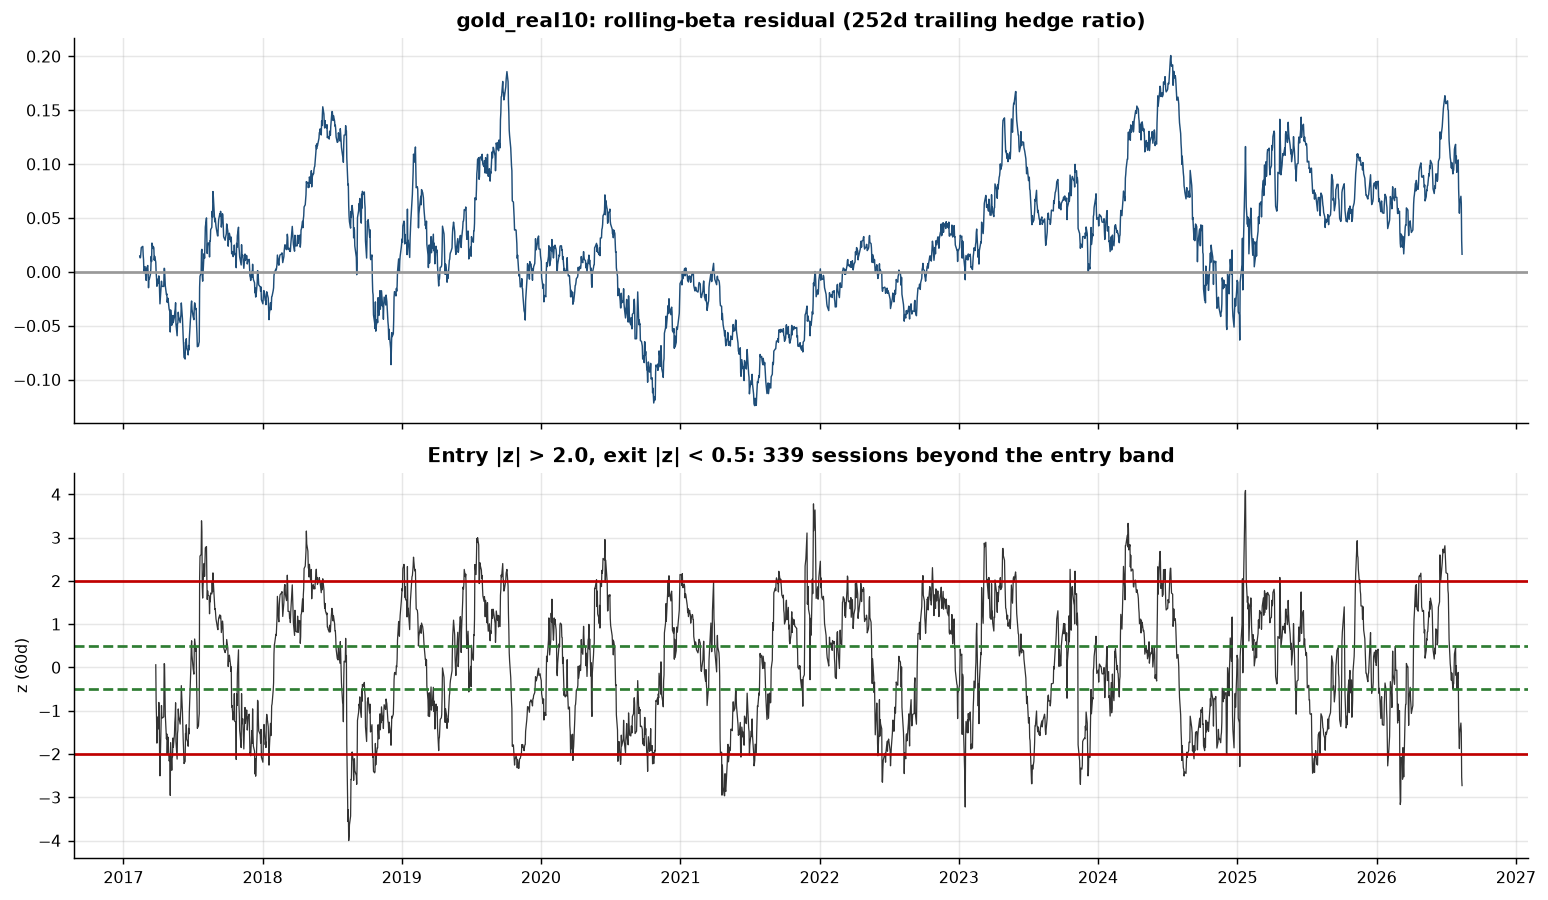

In [7]:
zscores, residuals = results["rv_zscores"], results["rv_residuals"]
name = relative_value.PRIMARY_PAIR
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(residuals.index, residuals[name], linewidth=0.8, color="#1f4e79")
axes[0].axhline(0, color="#999999"); axes[0].grid(alpha=0.3)
axes[0].set_title(f"{name}: rolling-beta residual (252d trailing hedge ratio)")
z = zscores[name]
axes[1].plot(z.index, z, linewidth=0.7, color="#333333")
for level in (signals.ENTRY_Z, -signals.ENTRY_Z):
    axes[1].axhline(level, color="#c00000")
for level in (signals.EXIT_Z, -signals.EXIT_Z):
    axes[1].axhline(level, color="#2e7d32", linestyle="--")
axes[1].grid(alpha=0.3); axes[1].set_ylabel("z (60d)")
axes[1].set_title(f"Entry |z| > {signals.ENTRY_Z}, exit |z| < {signals.EXIT_Z}: "
                  f"{int((z.abs() > signals.ENTRY_Z).sum())} sessions beyond the entry band")
plt.tight_layout(); plt.show()

## Why the hedge matters

A residual is a two-legged position. For the primary pair the residual does converge after an extreme reading, but most of the convergence arrives through the real-yield leg, which is not investable in a cash universe. Trading gold alone leaves the position wearing gold's drift, which over this window is much larger than the convergence.

In [8]:
results["rv_convergence"]

,horizon_days,n_rich,n_cheap,d_residual_when_rich,d_residual_when_cheap,leg_return_when_rich_pct,leg_return_when_cheap_pct,unconditional_leg_return_pct
0,5,187,150,-0.0022,0.0020,0.2758,0.5558,0.2181
1,10,187,150,-0.0046,0.0030,0.5005,0.8859,0.4433
2,21,187,150,-0.0075,0.0018,1.0452,1.7134,0.9493


The residual falls when it was rich and rises when it was cheap, so the mean reversion is there. But the tradable leg's return is positive in *both* states, because the unconditional drift dominates: most of the convergence arrives through the real-yield leg, which cannot be held in a cash universe. That is the whole argument for holding both legs, and it is why the hedged and single-leg variants are both backtested.

In [9]:
results["rv_betas"].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
gold_real10,-0.0741,0.1196,-0.3441,0.1876
wti_usd,-1.8596,5.2340,-11.8634,9.5817
breakeven_wti,0.8315,0.6989,-0.6681,3.0840
spx_vix,-0.0806,0.1217,-0.3922,0.3977
curve_hyoas,-7.4862,51.9741,-490.9910,118.2452


The hedge ratios are not stable either. `curve_hyoas` swings across hundreds of units, which is why it is analysed but never backtested: a spread whose hedge ratio is that unstable is not a spread.